# Targeted Semantic Search: Megas

In [2]:
import re
import numpy as np
import pandas as pd
from pprint import pprint

In [2]:
import pyarrow
import pyarrow.dataset


19.0.0
pyarrow OK


In [18]:
%pylab inline

df = pd.read_parquet('MEGAS_Clusters_Embeddings_Emotions.parquet')


In [ ]:
# load necessary columns
corpus_df = df[['ID', 'Chapters', 'Sentences', 'Embeddings', 'Updated_Cluster',
       'Clustered_Sentences', 'Size', 'Top_Keywords', 'Cluster_title2', 'neutral', 'anger', 'joy', 'sadness', 'fear',
       'trust', 'disgust', 'anticipation', 'surprise', 'Top Emotion',
       'Top Emotion Score']]

# Semantic search

In [11]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.14.0+cpu
False


In [13]:
from sentence_transformers import SentenceTransformer,util

In [ ]:
# Load the multilingual SBERT model
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')

In [16]:
#check the parameters
model

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'XLMRobertaModel'})
  (1): Pooling({'embedding_dimension': 768, 'pooling_mode': 'mean', 'include_prompt': True})
)

In [ ]:
# Add a new column named 'Author' with the content 'Kordatos'
corpus_df['Writer'] = 'Megas'

In [ ]:
# Group by cluster and display sentences per cluster
grouped = corpus_df.groupby("Cluster_title")["Sentences"].apply(list)

# To display each cluster and its sentences:
for cluster, sentences in grouped.items():
    print(f"\n--- Cluster {cluster} ---")
    for sent in sentences:
        print(f"- {sent}")

### Researcher-selected query propositions

The query propositions below were selected as analytically relevant through close reading and prior linguistic analysis. Each query is compared with all corpus sentences in the embedding space to retrieve semantically related formulations across lexical variation. in the corpus. 

In [734]:
#Introduce a query sentence and encode it

query = 'Αν αφεθώμεν ψυχροί και αδιάφοροι εις την όρεξιν και επιβολήν των Ψυχαριστών, θα παρουσιάσωμεν εις τα όμματα του κόσμου γλώσσαν διαστρεβλωμένην γλώσσαν Σκύθου τοξότου του αρχαίου Κωμικού και των χαμάληδων του Ψυχάρη, τον γελοίον και επάρατον μαλλιαρισμόν .'

#query = 'διότι δεν θέλουν να κλονίσουν τα θεμέλια του χτίριου της γλώσσης των μεταβάλλοντες την παλαιάν ορθογραφίαν Μα την μνήμην του Κοραή αδίκως επάνω εις τον θυμόν του ο μέγας αληθώς ποιητής του Ύμνου προς την Ελευθερίαν της Ελλάδος έβλεπε σοφολογιωτάτους κοράκους χειρότερους από τον κόρακα εκεί όπου δεν υπήρχον κακώς εμάντευεν ότι η ελευθερία και η γλώσσα θέλουν πατήση ογλήγορα στα σοφολογιωτατίστικα κεφάλια με όσην βίαν και αν θελήσουν οι οπαδοί του να επιβάλουν τον αχαλίνωτον χυδαϊσμόν ως εθνικήν γλώσσαν.'
#query = 'Αυτοί ας όψωνται , οι μεν διά την ψυχράν αδιαφορίαν, οι δε διά την υποστήριξιν προς επικράτησιν της επικινδύνου ιδεολογίας των Ψυχαριστών, προς επιβολήν του χυδαίου δημοτικισμού εις τα σχολεία του λαού.'
#query = 'ποίαι μεταρρυθμίσεις ήρχισαν να γίνωνται εις τα Σχολεία από της ιδρύσεως διδασκαλείων παρ ημίν, έρχεται ως αυτόκλητος δημόσιος κατήγορος ο Ψυχάρης και φωνάζει:'
#query =  'να διαιρέση δε τους ενθουσιώδης λειτουργούς της Παιδείας εις αντιμαχόμενα στρατόπεδα προς ανεπανόρθωτον βλάβην της μορφώσεως των νεαρών μας γενεών!''
#query = 'o Poϊδης του οποίου Τά Είδωλα πολλών λογίων συνεκλόνιζον την πίστιν προς την καθαρεύουσαν, τότε πλέον ο Χατζηδάκις ενόμισε καθήκον υπό της επιστήμης επιβεβλημένον να σταματήση την επικίνδυνον τροπήν του ζητήματος προς εκχυδαϊσμόν της ωραίας εθνικής μας γλώσσης. 	Megas
#query = 'Διότι πως άλλως θα παρεπλάνουν τους δημοδιδασκάλους, ίνα δώσουν λευκήν ψήφον προς εισαγωγήν του ψυχαρικού τέρατος εις τα σχολεία του λαού;'
#query = 'Μόνον κόλακες και συμφεροντολόγοι ημπορούν να μη βλέπουν την εκ του μαλλιαρισμού ανεπανόρθωτον βλάβην εις την Εθνικήν ημών γλώσσαν, την δημοσίαν ημών παίδευσιν.'
#query = 'Μα και αυτός ο Κοραής δεν έκανε καλό, γιατί κι αυτός εμπόδισε, με το κύρος και τα γραψίματά του, να καθιερωθεί στον πεζό λόγο και στην ποίηση η λαϊκή γλώσσα, δηλαδή να λυθεί το γλωσσικό μας ζήτημα σύμφωνα με τις υποδείξεις του Βηλαρά και του Καταρτζή.'
#query = 'Δεν είναι λοιπόν ύβρις εις την μνήμην του μακαρίτου ανδρός, να παρουσιάζουν τον σφοδρόν κατήγορον ως δήθεν συνήγορον της τερατολογίας των;'
#query = 'Μόνον μωροί και τυφλοί ημπορούν να παραδέχωνται ότι οι λόγοι των πληρεξουσίων του λαού εις την Βουλήν είναι ακατανόητοι, ασυγκίνητοι δε και κατάψυχροι ως νεκροί οι άλλοι βουλευταί και οι ακροαταί από τα θεωρεία, όλως δε αδιάφορος και αμέριμνος ο εκτός άλλος κόσμος διά τα εκεί λεγόμενα και ψηφιζόμενα.'
#query = 'Δεν φωνάζουν, δεν συκοφαντούν ότι και η απλή καθαρεύουσα είναι ΝΕΚΡΟΣ ΑΤΑΦΟΣ, δεν ενεργούν κρυφαίως και φανεραίως με τοιαύτα ψευδή και παράλογα επιχειρήματα να επιβάλουν εις τα σχολεία τον απαίσιον μαλλιαρισμόν'
#query = 'Τί είναι το τιμιώτερον να λέγεται κανείς πατριοδολάτρης καθαρευουσιάνος η Ψυχαρολάτρης , μαλλιαρός ;'
#query = 'Είχον, ως φαίνεται, ανάγκην νά σκιάσουν τό Ψυχάρειον τέρας υπό τήν δόξαν τού μεγάλου Ποιητού χάριν τών αφελών καί αμαθεστέρων επαδών τής Μαλλιαρωσύνης. '
#query = 'Ενθουσιώδης ζήλος προς επάνοδον των Ελικωνιάδων Μουσών εις την πάτριον γήν, έξοχος θαυμασμός προς την αθάνατον γλώσσαν του Ξενοφώντος και Πλάτωνος και Δημοσθένους, ασυγκράτητος πατριωτισμός και ελπίς εις το μέλλον της πατρίδος κάμνει τους αληθώς μεγάλους τούτους διδασκάλους του Γένους να ονειρεύωνται ανάστασιν της αρχαίας γλώσσης εις την Νέαν μας Ελλάδα!.'
#query = 'Ο δημοσιογράφος, έχων υπ όψει το όλον δημόσιον, ανθρώπους επαγγελματίας, βιομηχάνους, εμπόρους, τεχνίτας και πολλούς εκ του πολλού λαού, δεν ηδύνατο και δεν έπρεπε να μιμηθή την υπερκαθαρεύουσαν του Μοισιόδακος και Θεοτόκη, του Κόντου και του Σεμιτέλου διότι ολίγοι θα κατενόουν τα γραφόμενά του αλλά δεν επροτίμησε και τον άκρον δημοτικισμόν του Καταρτζή και Φιλιππίδου και Ψυχάρη'
#query = 'κανείς δεν αρέσκεται εις την χυδαιολογίαν των μπακάληδων της Ζαγοράς και των χαμάληδων της Κερκύρας και του Πειραιώς.' 
#query = 'τί έχουν να δικαιολοθούν οι καταργούντες εντελώς την Ι κλίσιν, οι Σκυθίζοντες εις την προφοράν, οι βλάμηδες πάσης ξενοφωνίας και χυδαιολογίας της αγοράς;'




In [735]:
#Encode the query
query_embedding = model.encode(query, convert_to_tensor=True)

In [736]:
# Compare the query with corpus sentence embeddings
util.cos_sim(query_embedding, corpus_embeddings[0])
#print("Cosine-Similarity:", cos_sim)

tensor([[0.7345]])

In [737]:
# Retrieve semantically similar corpus sentences
#top_k = 50 

# Define an exploratory cosine-similarity threshold
similarity_threshold = 0.60

In [ ]:
# Perform semantic search
top_k = len(corpus)

# Compare the query with corpus sentence embeddings
search_results = util.semantic_search(query_embedding, corpus_embeddings, top_k=top_k)[0]

# Filter the results based on the similarity threshold
filtered_results = [result for result in search_results if result['score'] >= similarity_threshold]
filtered_results

In [739]:
# Retrieve the 'Class' values based on the 'corpus_id' in the result
classes = [corpus_df.loc[item['corpus_id'], 'Writer'] for item in filtered_results]

In [740]:
# Create a list of dictionaries for the results
results_list = []
for item, class_label in zip(filtered_results, classes):
    results_list.append({
        'score': round(item['score'], 2),
        'sentence': corpus[item['corpus_id']],
        'Class': class_label
    })

# Create a DataFrame from the list of dictionaries
results_df0 = pd.DataFrame(results_list)
#results_df1 = pd.DataFrame(results_list)
#results_df2 = pd.DataFrame(results_list)
#results_df3 = pd.DataFrame(results_list)
#results_df4 = pd.DataFrame(results_list)
#results_df5 = pd.DataFrame(results_list)
#results_df6 = pd.DataFrame(results_list)
#results_df7 = pd.DataFrame(results_list)
#results_df8 = pd.DataFrame(results_list)
#results_df9 = pd.DataFrame(results_list)
#results_df10 = pd.DataFrame(results_list)
#results_df11 = pd.DataFrame(results_list)
#results_df12 = pd.DataFrame(results_list)

In [741]:
results_df0.shape

(952, 3)

In [742]:
# Print the resulting DataFrame
results_df0.head(50)

,score,sentence,Class
0,1.00,"Αν αφεθώμεν ψυχροί και αδιάφοροι εις την όρεξιν και επιβολήν των Ψυχαριστών, θα παρουσιάσωμεν εις τα όμματα του κόσμου γλώσσαν διαστρεβλωμένην, γλώσσαν Σκύθου τοξότου του αρχαίου Κωμικού και των χαμάληδων του Ψυχάρη, τον γελοίον και επάρατον μαλλιαρισμόν .",Megas
1,0.84,"Είδαμεν ανωτέρω τα τερατώδη και γελοία της Ψυχαρικής ιδεολογίας βλέπομεν και εις τους οπαδούς αυτής την ανωμαλίαν και ακαταστασίαν όσαι κεφαλαί, τόσαι και γλώσσης μορφαί όσαι γραμμαί, τόσαι και γλώσσης ανομοιότητες εκεί βλέπει τις απλήν καθαρεύουσαν, εδώ αυτήν ταύτην παραμορφωμένην και διεστραμμένην, ίνα φαίνεται ως δημοτική .",Megas
2,0.82,"Παραβάλλετε την γλώσσαν του Ριζοσπάστου και την γλώσσαν όλων των άλλων ημερησίων φύλλων και θα ίδετε ευθύς εις εκείνον κυριαρχούσαν την αναρχίαν εις την σύνθεσιν, όπως και εις τα μυαλά των αναγνωστών του, εδώ δε βασιλεύουσαν τάξιν και ομαλότητα ως προς το όλον της γλωσσικής συνθέσεως όστις δεν ετυφλώθη εκ συμπαθείας προς τον Ψυχαρισμόν και τον γελοίον Μαλλιαρισμόν, ούτος προθύμως και ειλικρινώς θα συνομολογήση ότι γλώσσα της δημοσιογραφίας παρ ημίν επί όλον αιώνα είναι η απλή καθαρεύουσα διότι αι εξαιρέσεις δεν αποτελούν την πλειονότητα και δεν βαρύνουν εις την κρίσιν μεγάλων ζητημάτων.",Megas
3,0.80,"Δίδει θέσιν τινά εις το απαρέμφατον, δοκιμάζων, αν θα γίνη ανεκτόν εις την γραφομένην γλώσσαν θεωρεί όμως ως υπερβολήν την είσοδον εις αυτήν πληθώρας δοτικών, την χρήσιν μέσων αορίστων, μονολεκτικών χρόνων, πολ λών τύπων των ειςμι ρημάτων κλπ. όσα απομακρύνουν την γλώσσαν από το απλούν ύφος και καθιστάνουν αυτήν ακατάληπτον εις τον λαόν.",Megas
4,0.80,"γ Ασπονδος διωγμός συνήθων αρχαίων λέξεων και προτίμησις ξένων και άκρως χυδαίων διά λόγους βαθείς ψυ χαρικούς , αφ ου έτσι μιλάει τ αδρέφι, ο χαμάλης της Χιός και του Γαλατά Ιλ.",Megas
5,0.80,"Διότι πως άλλως θα θριαμβεύση η ιδεολογία παι ραδόξων γλωσσοπλαστών, αν ψευδόμενοι δεν μεταφέρουν το είδωλον του Σολωμού εις την ακρότητα του Ψυχαρισμού των;",Megas
6,0.80,"Το μαρτυρεί η γλώσσα του Ψυχάρη, του Πάλλη, του Παλαμά, του Γληνού και Σια και παντός είδους στιχοπλόκων, διά τους οποίους άλλοι ξεκαρδίζονται και άλλοι απορούν, πως κατώρ θωσεν η πονηρία των δήθεν γλωσσομεταρρυθμιστών να επιβάλη τον γελοίον μαλλιαρισμόν εις τα Σχολεία του λαού!",Megas
7,0.80,"Ιδού, φίλοι συνάδελφοι, ποία αποκαλύπτεται η γλώσσα των Ψυχαριστών, ποία η φρικτή εικών Διβυκού τέρατος, το οποίον η κοινή γνώμη απεκάλεσε μαλλιαρισμόν .",Megas
8,0.79,"φανταζόμεθα την ΜΕΣΗΝ ΓΛΩΣΣΑΝ , όπως την ωνόμασεν ο Καλοσγούρος εις τας Κριτικάς",Megas
9,0.79,"Μετά τα τοιαύτα λαμπρά αποκαλυπτήρια πρέπει να είναί τις τυφλός και μωρός, αν νομίζη ότι ο Ψυχαρισμός είναι δημοτικισμός , ότι τα Ρωμαίϊκα των Ψυχαριστών είναι Ελληνικά Τίς από τον λαόν γράφει, τις ομιλεί η εννοεί την διεστραμμένην αυτήν γλώσ σαν;",Megas


In [ ]:
# Concatenate all sentences into a single text block
text_to_summarize = ' '.join(results_df0['sentence'])
text_to_summarize

In [747]:
# Generate a preliminary interpretive summary with an LLM
try:
    chat_completion = client.chat.completions.create(
        model= "gpt-4o",    
        messages=[
            {"role": "user", "content": f"Summarize the following text into a comprehensive sentence which can reflect the subjectivity of the text: \"{text_to_summarize}\""}
        ],
        max_tokens=100,  # we can adjust this based on the desired length of the title
        temperature=0.65  # we can djust for creativity level; higher is more liberal and creative 
    )

    # Check if there are choices and messages available
    if chat_completion.choices and len(chat_completion.choices) > 0:
        # Assuming the first choice is the one we want
        # Access message content
        message = chat_completion.choices[0].message.content  # Adjust this line based on the actual method/attribute
        print("Generated Title:", message)

        # Store the title in the DataFrame
        results_df0['Generated Title'] = message
    else:
        print("No title was generated.")

except Exception as e:
    print("An error occurred:", str(e))

Generated Title: The text expresses a strong critique of the "Ψυχαρισμός" movement, which aimed to reform the Greek language by promoting a version called "Demotic Greek." The author perceives this movement as a distortion of the language, comparing it to a "Scythian archer's tongue" and a "grotesque barbarization," and associates it with figures like Ψυχάρης, Πάλλης, Παλαμάς, and Γληνός. The text argues


In [ ]:
#check 
results_df0

In [750]:
results_df0['Idea'] = 'Barbaric Demotic of «Scythian archers and grocers»/Distiguished journals not for vine-diggers, woodcutters, goat herders and coolies'



### Additional query propositions

The same targeted semantic-search procedure was applied to additional researcher-selected propositions. The resulting groups are not mutually exclusive: a corpus sentence may be semantically related to more than one query.

In [611]:
results_df1['Idea'] = 'Enthusiasm and admiration for the ancient Greek language-historical and cultural heritage'

In [587]:
results_df2['Idea'] = 'The monster of malliarismos'

In [531]:
results_df3['Idea'] = 'Demoticists distrort the language by wrongfully arguing that katharevousa is dead'

In [474]:
results_df4['Idea'] = 'Psicharism as an absurd and dangerous ideology'

In [459]:
results_df5['Idea'] = 'The threat of vulgarism in schools-the middle path as a solution'

In [445]:
results_df6['Idea'] = 'Demotic seen as malliarismos threaten the national language'

### Combine retrieved passages

In [ ]:
pdList = [results_df0, results_df1, results_df2, results_df3, results_df4, results_df5, results_df6 ]  # List of my dataframes
combined_df = pd.concat(pdList, ignore_index=True, sort=False)

In [772]:
combined_df

,score,sentence,Class,Generated Title,Idea
0,1.00,"διότι δεν θέλουν να κλονίσουν τα θεμέλια του χτίριου της γλώσσης των μεταβάλλοντες την παλαιάν ορθογραφίαν Μα την μνήμην του Κοραή, αδίκως επάνω εις τον θυμόν του ο μέγας αληθώς ποιητής του Ύμνου προς την Ελευθερίαν της Ελλάδος έβλεπε σοφολογιωτάτους κοράκους χειρότερους από τον κόρακα εκεί, όπου δεν υπήρχον κακώς εμάντευεν ότι η ελευθερία και η γλώσσα θέλουν πατήση ογλήγορα στα σοφολογιωτατίστικα κεφάλια , με όσην βίαν και αν θελήσουν οι οπαδοί του να επιβάλουν τον αχαλίνωτον χυδαϊσμόν ως εθνικήν γλώσσαν.",Megas,"The text discusses the ongoing debate in Greece over the evolution and standardization of the Greek language, highlighting the tension between maintaining traditional forms and adapting to contemporary usage, with figures like Koraes advocating for a middle ground, while others push for either archaic purity or modern simplification, leading to divisions among scholars and impacting national education and identity.",Demotic seen as malliarismos threaten the national language
1,0.88,"Εις την φωνήν του Κοραή κατά του χυδαϊσμού και του μακαρονισμού εξεγείρονται σφοδρότερον αι φάλαγγες των δημοτικιστών, προφαίνονται ήδη θαρραλεώτεροι υπέρμαχοι του αρχαϊσμού, κYρύττοντες το δόγμα επιστροφής εις την γλώσσαν του Ξενοφώντος, του Πλάτωνος και Δημοσθένους, ούτω δε επί Κοραή έχομεν εις την Ιστορίαν της γλώσση, άσπονδον γραφιδοπόλεμον μεταξύ των λογίων του Έθνους, εν ώ συγχρόνως εις πόλεις και όρη και βουνά το σάλπισμα του Ρήγα προπαρασκεύαζε και εκάλει τα γενναία παλληκάρια εις άλλον μέγαν υπέρ πίστεως και πατρίδος αγώνα!",Megas,"The text discusses the ongoing debate in Greece over the evolution and standardization of the Greek language, highlighting the tension between maintaining traditional forms and adapting to contemporary usage, with figures like Koraes advocating for a middle ground, while others push for either archaic purity or modern simplification, leading to divisions among scholars and impacting national education and identity.",Demotic seen as malliarismos threaten the national language
2,0.87,"Αλλ όπως προ αιώνς εις ομοίαν κρίσιμον ώραν επικινδύνου τροπής της εθνικής γλώσσης εις τον χυδαϊσμόν Θεία χείρ καθωδήγησε τον αοίδιμον Κοραήν εις σωτηρίαν αυτής, ούτω και σήμερον, τις οίδεν, αν η Αυτή χείρ δεν επέδειξεν εις τον Ελευθέριον Βενιζέλον να κατέλθη εις το γλωσσικόν πεδίον και να βροντοφωνήση προς τους αντιμαχομένους εις τα άκρα ασπόνδους αγωνιστάς Ιδού η μέση οδός!",Megas,"The text discusses the ongoing debate in Greece over the evolution and standardization of the Greek language, highlighting the tension between maintaining traditional forms and adapting to contemporary usage, with figures like Koraes advocating for a middle ground, while others push for either archaic purity or modern simplification, leading to divisions among scholars and impacting national education and identity.",Demotic seen as malliarismos threaten the national language
3,0.87,"Εμφανίζεται εις το στρατόπεδον των δεινών αντιπάλων ο Αδαμάντιος Κοραής, κήρυξ και απόστολος της αληθινής μέσης οδού προς μόρφωσιν της Εθνικής γλώσσης και ιδού όλως απροσδοκήτως προφαίνεται εις άλλο αντίθετον άκρον μικρά φάλαγξ λογίων, έχουσα εις την μεγάλην της σημαίαν γραμμένον το παράδοξον δόγμα ΕΠΙΣΤΡΟΦΗ ΠΡΟΣ ΤΟ ΕΝΔΟΞΟΝ ΠΑΡΕΛΘΟΝ !",Megas,"The text discusses the ongoing debate in Greece over the evolution and standardization of the Greek language, highlighting the tension between maintaining traditional forms and adapting to contemporary usage, with figures like Koraes advocating for a middle ground, while others push for either archaic purity or modern simplification, leading to divisions among scholars and impacting national education and identity.",Demotic seen as malliarismos threaten the national language
4,0.87,"Ο λογιώτατος σχολάρχης ομολογεί ότι Ένεκα τούτων απεφάσισε Προσθέτει προς τούτοις ότι Αναγκάζεται διά την φυσικήν πτωχίαν του Κοινού Υφους να λεξοποιήση ο σοφός ιερομόναχος και καταφεύγει εις την πλ

In [773]:
combined_df['Idea'].unique()

array(['Demotic seen as malliarismos threaten the national language',
       'The threat of vulgarism in schools-the middle path as a solution',
       'Demoticists distrort the language by wrongfully arguing that katharevousa is dead',
       'The monster of malliarismos',
       'Enthusiasm and admiration for the ancient Greek language-historical and cultural heritage',
       'Barbaric Demotic of «Scythian archers and grocers» / Distiguished journals not for vine-diggers, woodcutters, goat herders and coolies'],
      dtype=object)

In [774]:
idea_counts = combined_df['Idea'].value_counts()
print(idea_counts)

Idea
Barbaric Demotic of «Scythian archers and grocers» / Distiguished journals not for vine-diggers, woodcutters, goat herders and coolies    952
Demotic seen as malliarismos threaten the national language                                                                               755
The monster of malliarismos                                                                                                               534
The threat of vulgarism in schools-the middle path as a solution                                                                          317
Enthusiasm and admiration for the ancient Greek language-historical and cultural heritage                                                 255
Demoticists distrort the language by wrongfully arguing that katharevousa is dead                                                          63
Name: count, dtype: int64


### Interpretation of counts

Counts and proportions below refer to sentences retrieved for each query proposition. They should not be interpreted as frequencies of mutually exclusive ideological categories, because the same sentence may be retrieved by more than one query. Where proportions are used, they are normalized against the number of eligible corpus sentences.


### Visualize retrieval rates

In [ ]:
import matplotlib.pyplot as plt


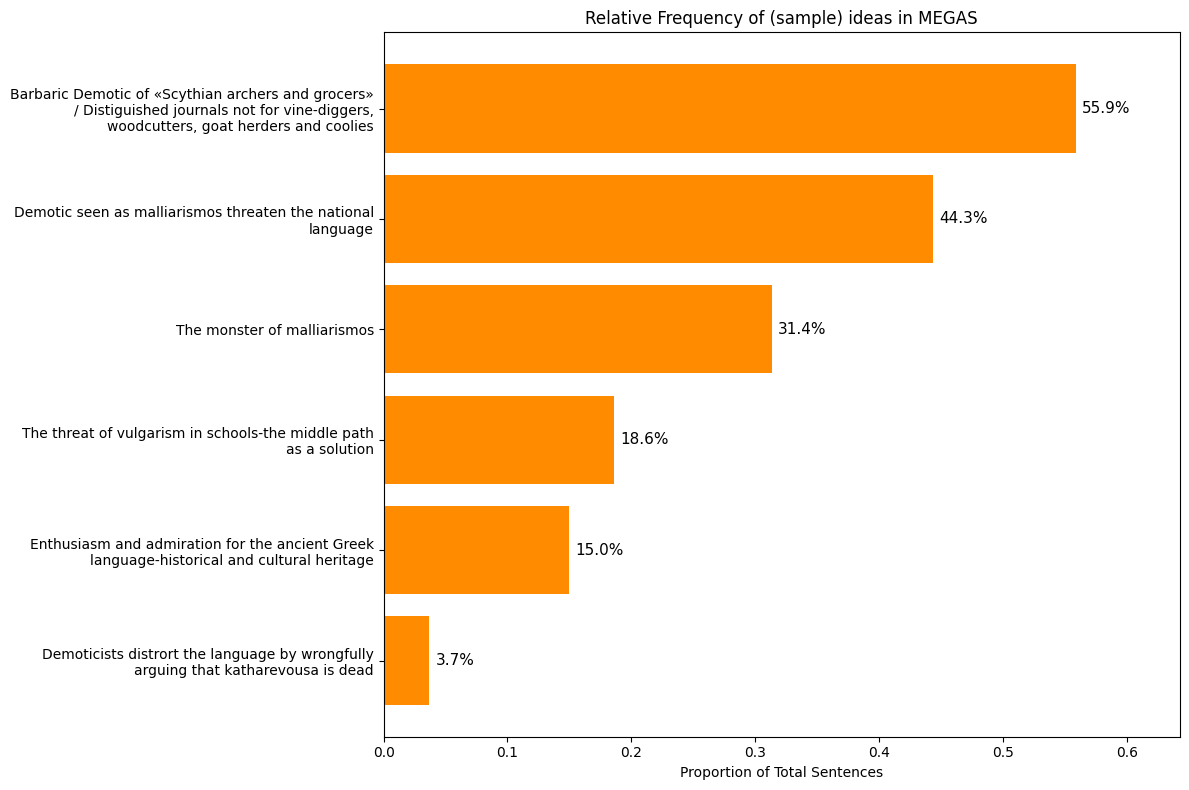

In [784]:
import textwrap

# Your data
idea_counts = combined_df['Idea'].value_counts()
idea_ratios = idea_counts / 1703  # Normalize
idea_ratios = idea_ratios.sort_values()

# Wrap long labels for better layout
wrapped_labels = ['\n'.join(textwrap.wrap(label, width=50)) for label in idea_ratios.index]

# Plot
plt.figure(figsize=(12, 8))
bars = plt.barh(wrapped_labels, idea_ratios.values, color='darkorange')

# Annotate with percentages
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, 
             bar.get_y() + bar.get_height() / 2,
             f"{width*100:.1f}%", 
             va='center', fontsize=11)

plt.xlabel("Proportion of Total Sentences")
plt.title("Relative Frequency of (sample) ideas in MEGAS")
plt.xlim(0, idea_ratios.max() * 1.15)
plt.tight_layout()
plt.savefig("Ideas_MEGAS.png", bbox_inches='tight')
plt.show()